<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP05/HFversion_fixed_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install datasets

In [ ]:
#NSMC읽기
import urllib.request
import zipfile
import os

url = "https://github.com/e9t/nsmc/raw/master/ratings.txt"

save_path = "ratings.txt"

urllib.request.urlretrieve(url, save_path)

print("다운로드 완료")

다운로드 완료


In [ ]:
#train/test로 나눠서 읽기
import urllib.request

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

urllib.request.urlretrieve(train_url, "ratings_train.txt")
urllib.request.urlretrieve(test_url, "ratings_test.txt")

print("train/test 다운로드 완료")

train/test 다운로드 완료


In [ ]:
import pandas as pd

train_df = pd.read_csv(
    "ratings_train.txt",
    sep="\t"
)

test_df = pd.read_csv(
    "ratings_test.txt",
    sep="\t"
)

print(train_df.head())

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [ ]:
#결측치 제거
train_df = train_df.dropna()
test_df = test_df.dropna()

print(len(train_df))
print(len(test_df))

149995
49997


In [ ]:
#Huggingface dataset으로 변환하기
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 49997
    })
})


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "klue/bert-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

In [ ]:
# document 컬럼 제거 (이미 제거된 경우 건너뜀) 및 label -> labels 리네임
if "document" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["document"])

if "label" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# __index_level_0__ 컬럼도 학습에 불필요하므로 제거
if "__index_level_0__" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["__index_level_0__"])

if "id" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["id"])

tokenized_dataset.set_format("torch")

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
!pip install -U transformers evaluate

In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    f1_score = f1.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

In [ ]:
import transformers

print(transformers.__version__)

5.9.0


In [ ]:
import os
from transformers import TrainingArguments, Trainer

# transformers 5.2부터 logging_dir 인자가 제거됨 -> 환경 변수로 설정
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",          # transformers 5.x에서 evaluation_strategy -> eval_strategy로 변경됨
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=2,
    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"                # wandb 등 외부 로깅 비활성화
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],

    processing_class=tokenizer,     # transformers 5.x에서 tokenizer -> processing_class로 변경됨
    compute_metrics=compute_metrics
)

## Bucketing 실험: 연산 속도 vs 모델 성능 Trade-off

기존 코드는 모든 샘플을 `max_length=128`로 패딩(고정 길이 패딩)합니다. NSMC는 짧은 리뷰가 많아 대부분이 `[PAD]` 토큰으로 채워지고, 이 부분에도 self-attention 연산이 수행되어 낭비가 큽니다.

Bucketing은 비슷한 길이의 샘플끼리 묶어 배치 내 패딩량을 최소화하는 기법입니다. 세 가지 조건을 비교합니다.

| 조건 | 패딩 방식 | 배치 구성 |
|---|---|---|
| **A. Baseline** | `max_length=128` 고정 | 랜덤 셔플 |
| **B. Dynamic Padding** | 배치 내 최대 길이까지만 | 랜덤 셔플 |
| **C. Bucketing (length-grouped)** | 배치 내 최대 길이까지만 | 길이 기준 그룹화 (`group_by_length=True`) |

동일한 모델/하이퍼파라미터/seed로 학습 시간과 accuracy, f1을 비교하여 trade-off를 분석합니다.

### 1) 토큰 길이 분포 확인
고정 패딩이 얼마나 비효율적인지 먼저 시각화로 확인합니다.

평균 길이: 22.6
중앙값:    18.0
95%:       63.0
최대:      127
max_length=128 대비 평균 사용률: 17.7%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


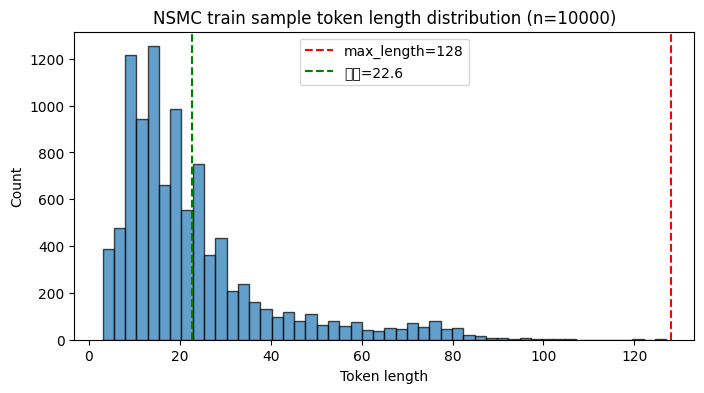

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 학습 데이터 토큰 길이 (special token 포함 전 실제 토큰 수)
train_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in train_df["document"].tolist()[:10000]]

print(f"평균 길이: {np.mean(train_lengths):.1f}")
print(f"중앙값:    {np.median(train_lengths):.1f}")
print(f"95%:       {np.percentile(train_lengths, 95):.1f}")
print(f"최대:      {np.max(train_lengths)}")
print(f"max_length=128 대비 평균 사용률: {np.mean(train_lengths)/128*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(128, color="red", linestyle="--", label="max_length=128")
plt.axvline(np.mean(train_lengths), color="green", linestyle="--", label=f"평균={np.mean(train_lengths):.1f}")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("NSMC train sample token length distribution (n=10000)")
plt.legend()
plt.show()

### 2) 두 종류의 토크나이즈 데이터셋 준비
- `padded_dataset`: `padding="max_length"` (조건 A용, 기존 `tokenized_dataset`을 그대로 사용해도 동일)
- `unpadded_dataset`: 패딩 없음 → DataCollator가 배치마다 동적으로 패딩 (조건 B, C용)

공정한 비교를 위해 실험 규모는 줄입니다(train 20k, test 5k). 전체로 돌리려면 슬라이싱을 제거하세요.

In [ ]:
from datasets import Dataset, DatasetDict

# 실험용 서브셋 (시간 절약). 전체로 돌리려면 아래 슬라이싱 제거
SUBSET_TRAIN = 20000
SUBSET_TEST  = 5000

small_train_df = train_df.sample(n=SUBSET_TRAIN, random_state=42).reset_index(drop=True)
small_test_df  = test_df.sample(n=SUBSET_TEST,  random_state=42).reset_index(drop=True)

small_dataset = DatasetDict({
    "train": Dataset.from_pandas(small_train_df),
    "test":  Dataset.from_pandas(small_test_df),
})

def tokenize_padded(examples):
    return tokenizer(examples["document"], truncation=True, padding="max_length", max_length=128)

def tokenize_unpadded(examples):
    # 패딩 없이 토크나이즈 → 콜레이터가 배치별 동적 패딩 처리
    return tokenizer(examples["document"], truncation=True, max_length=128)

padded_dataset   = small_dataset.map(tokenize_padded,   batched=True)
unpadded_dataset = small_dataset.map(tokenize_unpadded, batched=True)

def cleanup(ds):
    cols_to_remove = [c for c in ["document", "id", "__index_level_0__"] if c in ds["train"].column_names]
    if cols_to_remove:
        ds = ds.remove_columns(cols_to_remove)
    if "label" in ds["train"].column_names:
        ds = ds.rename_column("label", "labels")
    return ds

padded_dataset   = cleanup(padded_dataset)
unpadded_dataset = cleanup(unpadded_dataset)

print("padded_dataset  :", padded_dataset)
print("unpadded_dataset:", unpadded_dataset)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

padded_dataset  : DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})
unpadded_dataset: DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})


### 3) 실험 실행 함수
동일한 하이퍼파라미터/seed로 모델을 매번 새로 초기화하여 세 조건을 학습/평가합니다.

In [ ]:
import os, time, gc, torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    DataCollatorWithPadding, default_data_collator,
    set_seed,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

def run_experiment(name, train_ds, eval_ds, data_collator, group_by_length, num_epochs=1, batch_size=32, seed=42):
    """한 가지 조건으로 학습/평가하고 메트릭과 소요시간 반환."""
    set_seed(seed)
    # 매 실험마다 모델 새로 로드 (동일 출발점 보장)
    model = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

    # transformers 5.x에서 group_by_length 인자가 train_sampling_strategy로 통합됨
    sampling_strategy = "group_by_length" if group_by_length else "random"

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="no",                       # 실험이므로 체크포인트 저장 생략
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=100,
        train_sampling_strategy=sampling_strategy,  # ← Bucketing 핵심 (transformers 5.x API)
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # 학습 시간 측정
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    trainer.train()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    train_time = time.time() - t0

    # 평가
    eval_metrics = trainer.evaluate()

    result = {
        "name": name,
        "train_time_sec": train_time,
        "eval_accuracy": eval_metrics.get("eval_accuracy"),
        "eval_f1": eval_metrics.get("eval_f1"),
        "eval_loss": eval_metrics.get("eval_loss"),
    }

    # 메모리 정리
    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

### 4) 세 가지 조건 학습/평가 실행
GPU 환경 기준 각 실험에 수 분이 소요됩니다. CPU만 있다면 `SUBSET_TRAIN`을 더 줄이세요.

In [ ]:
dynamic_collator = DataCollatorWithPadding(tokenizer=tokenizer)

results = []

# A. Baseline: 고정 길이 패딩 (max_length=128)
results.append(run_experiment(
    name="A_fixed_padding",
    train_ds=padded_dataset["train"],
    eval_ds=padded_dataset["test"],
    data_collator=default_data_collator,
    group_by_length=False,
))

# B. Dynamic Padding: 배치별 동적 패딩, 랜덤 셔플
results.append(run_experiment(
    name="B_dynamic_padding",
    train_ds=unpadded_dataset["train"],
    eval_ds=unpadded_dataset["test"],
    data_collator=dynamic_collator,
    group_by_length=False,
))

# C. Bucketing: 길이 기준 그룹화 + 배치별 동적 패딩
results.append(run_experiment(
    name="C_bucketing",
    train_ds=unpadded_dataset["train"],
    eval_ds=unpadded_dataset["test"],
    data_collator=dynamic_collator,
    group_by_length=True,
))

for r in results:
    print(r)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.273837,0.316573,0.871200,0.870214


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.273837,0.316573,1,0.871200,0.870214


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.293378,0.311674,0.873400,0.873121


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.293378,0.311674,1,0.873400,0.873121


{'name': 'A_fixed_padding', 'train_time_sec': 452.8767385482788, 'eval_accuracy': 0.8712, 'eval_f1': 0.8702136235388956, 'eval_loss': 0.31657305359840393}
{'name': 'B_dynamic_padding', 'train_time_sec': 291.17439889907837, 'eval_accuracy': 0.8736, 'eval_f1': 0.8718052738336713, 'eval_loss': 0.3192636966705322}
{'name': 'C_bucketing', 'train_time_sec': 115.22823095321655, 'eval_accuracy': 0.8734, 'eval_f1': 0.8731208659049909, 'eval_loss': 0.31167352199554443}


### 5) 결과 비교 및 분석
학습 시간, accuracy, f1을 표와 그래프로 시각화합니다.

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
baseline_time = df.loc[df["name"] == "A_fixed_padding", "train_time_sec"].iloc[0]
df["speedup_vs_baseline"] = baseline_time / df["train_time_sec"]
df["time_reduction_%"] = (1 - df["train_time_sec"] / baseline_time) * 100

print(df.to_string(index=False))
df

             name  train_time_sec  eval_accuracy  eval_f1  eval_loss  speedup_vs_baseline  time_reduction_%
  A_fixed_padding      452.876739         0.8712 0.870214   0.316573             1.000000          0.000000
B_dynamic_padding      291.174399         0.8736 0.871805   0.319264             1.555345         35.705596
      C_bucketing      115.228231         0.8734 0.873121   0.311674             3.930259         74.556381


,name,train_time_sec,eval_accuracy,eval_f1,eval_loss,speedup_vs_baseline,time_reduction_%
0,A_fixed_padding,452.876739,0.8712,0.870214,0.316573,1.000000,0.000000
1,B_dynamic_padding,291.174399,0.8736,0.871805,0.319264,1.555345,35.705596
2,C_bucketing,115.228231,0.8734,0.873121,0.311674,3.930259,74.556381


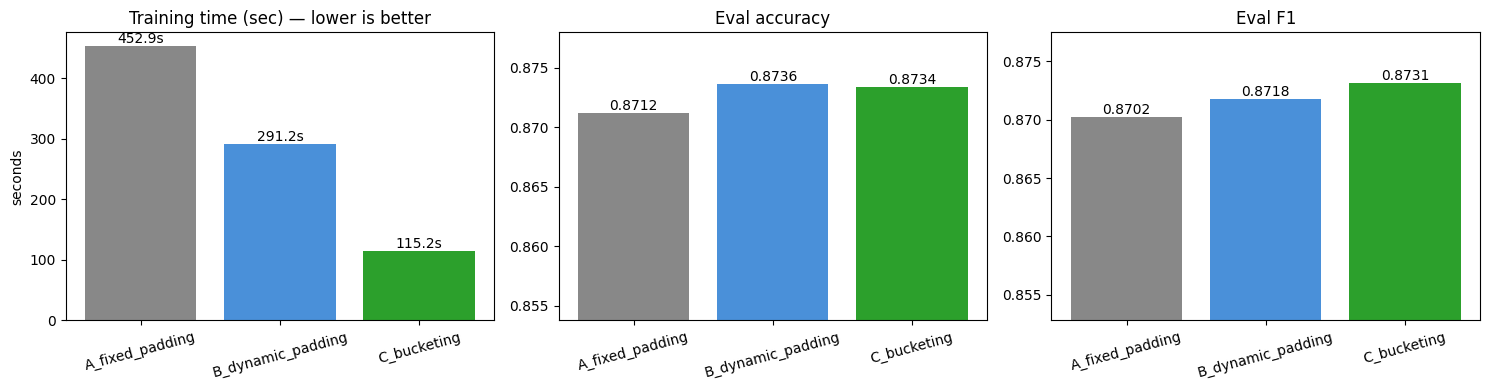

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = df["name"].tolist()
colors = ["#888", "#4a90d9", "#2ca02c"]

axes[0].bar(names, df["train_time_sec"], color=colors)
axes[0].set_title("Training time (sec) — lower is better")
axes[0].set_ylabel("seconds")
for i, v in enumerate(df["train_time_sec"]):
    axes[0].text(i, v, f"{v:.1f}s", ha="center", va="bottom")

axes[1].bar(names, df["eval_accuracy"], color=colors)
axes[1].set_title("Eval accuracy")
axes[1].set_ylim(min(df["eval_accuracy"])*0.98, max(df["eval_accuracy"])*1.005)
for i, v in enumerate(df["eval_accuracy"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

axes[2].bar(names, df["eval_f1"], color=colors)
axes[2].set_title("Eval F1")
axes[2].set_ylim(min(df["eval_f1"])*0.98, max(df["eval_f1"])*1.005)
for i, v in enumerate(df["eval_f1"]):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 6) 결과 해석 가이드

실제 수치는 GPU/CPU 환경, 서브셋 크기, 랜덤성에 따라 달라지지만 일반적으로 다음 경향이 관찰됩니다.

**연산 속도 측면**
- **A → B**: Dynamic Padding만으로도 학습 시간이 줄어듭니다. NSMC 평균 길이가 128보다 훨씬 짧기 때문에, 배치별 최대 길이만 패딩하면 `[PAD]` 토큰 위 연산이 사라집니다.
- **B → C**: 길이 기준 그룹화를 추가하면 배치 안에서 길이 편차가 줄어 패딩량이 더 감소합니다. 보통 가장 빠릅니다.

**모델 성능 측면**
- accuracy/f1은 세 조건이 통계적으로 유의한 차이 없이 거의 비슷하게 나오는 경우가 많습니다. 패딩 위치는 attention mask로 마스킹되므로, 패딩 방식 자체가 forward 연산 결과를 바꾸지는 않기 때문입니다.
- 다만 **C(group_by_length=True)** 는 배치 구성을 길이로 그룹화하면서 셔플이 약해지므로, SGD의 stochasticity가 줄어 일반화 성능이 미세하게 떨어질 수 있습니다(특히 epoch 수가 적을수록 두드러짐).

**Trade-off 결론**
- **Dynamic Padding(B)** 은 "공짜 점심"에 가깝습니다 — 성능 손실 없이 속도가 빨라집니다.
- **Bucketing(C)** 은 추가 속도 향상의 대가로 약간의 성능 변동성을 받아들이는 선택입니다. 데이터셋 규모가 크고 epoch이 충분하면 그 차이는 거의 사라집니다.
- 즉 실험에서 관찰되는 trade-off는 "극적인 성능 저하 vs 큰 속도 향상"이라기보다 "미세한 일반화 변동 vs 명확한 속도 향상"이며, 실용적으로는 Bucketing이 선호됩니다.

## NSMC vs IMDB: 데이터셋 간 성능 비교 실험

동일한 fine-tuning 파이프라인을 NSMC(한국어)와 IMDB(영어)에 적용하여 데이터셋 특성에 따른 성능 차이를 분석합니다.

**실험 설계**

| 항목 | NSMC | IMDB |
|---|---|---|
| 언어 | 한국어 | 영어 |
| 도메인 | 네이버 영화 리뷰 (짧은 댓글) | IMDB 영화 리뷰 (긴 본문) |
| 모델 | `klue/bert-base` | `bert-base-uncased` |
| 텍스트 컬럼 | `document` | `text` |
| 레이블 | 0/1 (부정/긍정) | 0/1 (부정/긍정) |
| 평균 토큰 길이 | ~25 | ~250 |

**통제 변수** (공정 비교를 위해 동일 유지)
- `max_length=128`, batch size, learning rate, epoch, optimizer, seed
- 데이터 규모(서브셋 크기) 동일

**관찰 포인트**
1. **언어/모델 적합도**: 각 언어 전용 모델이 해당 언어에서 어느 정도 성능을 내는가
2. **텍스트 길이의 영향**: IMDB는 긴 리뷰가 많아 `max_length=128`로 잘릴 가능성이 큼
3. **학습 안정성**: 같은 epoch에서 수렴 양상의 차이

---
# STEP 4. Fine-tuning을 통한 모델 성능(accuracy) 향상

**목표**: 데이터 전처리와 `TrainingArguments` 조정을 통해 NSMC 평가 정확도 **90% 이상** 달성.

**개선 전략**

1. **데이터 전처리 강화**
   - 결측치 제거 (기존)
   - 중복 리뷰 제거 (NSMC에는 동일 문장이 반복되는 경우가 있음)
   - 공백 정규화 (앞뒤 공백, 연속 공백 통합)

2. **`TrainingArguments` 튜닝**
   - `num_train_epochs`: 2 → **3** (NSMC + BERT는 보통 3 epoch에서 수렴)
   - `warmup_ratio=0.1` 추가 (초반 학습 안정화)
   - `load_best_model_at_end=True` + `metric_for_best_model="f1"` (최고 성능 에폭 자동 선택)
   - `weight_decay=0.01` 유지
   - `fp16=True` (GPU 환경이므로 학습 속도 ↑, 메모리 ↓)

3. **전체 데이터 사용** (서브셋이 아닌 NSMC 전체 ~14.6만 train / 5만 test)

이 섹션은 **고정 길이 패딩(`padding="max_length", max_length=128`)** baseline으로, STEP 5의 Bucketing과 비교 기준이 됩니다.

## 4-1. 데이터 전처리 강화

In [ ]:
import pandas as pd
import re

def preprocess(df):
    df = df.copy()
    # 1) 결측치 제거
    df = df.dropna(subset=["document", "label"])
    # 2) 공백 정규화: 앞뒤 strip + 연속 공백 → 단일 공백
    df["document"] = df["document"].astype(str).str.strip()
    df["document"] = df["document"].apply(lambda s: re.sub(r"\s+", " ", s))
    # 3) 빈 문자열 제거
    df = df[df["document"].str.len() > 0]
    # 4) 중복 제거 (같은 텍스트의 동일 라벨 중복)
    df = df.drop_duplicates(subset=["document", "label"])
    # 5) 같은 텍스트인데 라벨이 다른 행 → 노이즈로 보고 제거
    dup_text = df[df.duplicated(subset=["document"], keep=False)]
    if len(dup_text) > 0:
        df = df[~df["document"].isin(dup_text["document"])]
    return df.reset_index(drop=True)

train_df_v2 = preprocess(train_df)
test_df_v2  = preprocess(test_df)

print(f"전처리 전: train={len(train_df):>7,}, test={len(test_df):>6,}")
print(f"전처리 후: train={len(train_df_v2):>7,}, test={len(test_df_v2):>6,}")
print(f"라벨 분포 (train): \n{train_df_v2['label'].value_counts().to_string()}")

전처리 전: train=149,995, test=49,997
전처리 후: train=146,025, test=49,110
라벨 분포 (train): 
label
0    73272
1    72753


## 4-2. 토크나이즈 (고정 길이 패딩, baseline)

In [ ]:
from datasets import Dataset, DatasetDict

step4_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df_v2),
    "test":  Dataset.from_pandas(test_df_v2),
})

MAX_LEN = 128

def tokenize_fixed(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        padding="max_length",     # ← 고정 길이 패딩 (baseline)
        max_length=MAX_LEN,
    )

step4_tokenized = step4_dataset.map(tokenize_fixed, batched=True)

# 학습에 불필요한 컬럼 정리
drop_cols = [c for c in ["document", "id", "__index_level_0__"] if c in step4_tokenized["train"].column_names]
if drop_cols:
    step4_tokenized = step4_tokenized.remove_columns(drop_cols)
if "label" in step4_tokenized["train"].column_names:
    step4_tokenized = step4_tokenized.rename_column("label", "labels")

step4_tokenized.set_format("torch")
print(step4_tokenized)

Map:   0%|          | 0/146025 [00:00<?, ? examples/s]

Map:   0%|          | 0/49110 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 146025
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49110
    })
})


## 4-3. 학습 (튜닝된 `TrainingArguments`)
GPU 환경에서 약 30~50분 소요.

In [ ]:
import os, time
import torch
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    default_data_collator, set_seed,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs_step4"
set_seed(42)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_v2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

model_step4 = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./results_step4",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    num_train_epochs=3,                # 1→3: 충분히 수렴
    learning_rate=2e-5,                # BERT fine-tuning 표준
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,                  # 초반 학습 안정화
    weight_decay=0.01,
    lr_scheduler_type="linear",

    fp16=True,                         # GPU 학습 가속

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=200,
    report_to="none",
    seed=42,
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=step4_tokenized["train"],
    eval_dataset=step4_tokenized["test"],
    processing_class=tokenizer,
    data_collator=default_data_collator,   # 고정 패딩이므로 기본 collator
    compute_metrics=compute_metrics_v2,
)

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
trainer_step4.train()
if torch.cuda.is_available(): torch.cuda.synchronize()
step4_train_time = time.time() - t0

step4_metrics = trainer_step4.evaluate()
print("\n=== STEP 4 결과 ===")
print(f"학습 시간    : {step4_train_time:.1f} sec ({step4_train_time/60:.2f} min)")
print(f"eval_accuracy: {step4_metrics['eval_accuracy']:.4f}")
print(f"eval_f1      : {step4_metrics['eval_f1']:.4f}")
print(f"eval_loss    : {step4_metrics['eval_loss']:.4f}")
print(f"\n목표(90%) 달성 여부: {'✅ 달성' if step4_metrics['eval_accuracy'] >= 0.90 else '❌ 미달'}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256506,0.248097,0.901222,0.904306
2,0.184016,0.237872,0.907310,0.908126
3,0.122312,0.296552,0.906842,0.908230


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.122312,0.237872,3,0.907310,0.908126



=== STEP 4 결과 ===
학습 시간    : 3025.9 sec (50.43 min)
eval_accuracy: 0.9073
eval_f1      : 0.9081
eval_loss    : 0.2379

목표(90%) 달성 여부: ✅ 달성


---
# STEP 5. Bucketing 적용 학습 및 STEP 4와 비교

**Dynamic Padding과 Bucketing 개념**

- **Dynamic Padding**: 모든 샘플을 `max_length=128`로 패딩하는 대신, **배치 내 가장 긴 시퀀스 길이까지만** 패딩. `DataCollatorWithPadding`이 처리. NSMC처럼 평균 길이가 짧은 데이터에서는 패딩 토큰 위의 불필요한 attention 연산이 크게 줄어듦.
- **Bucketing (`group_by_length=True` / 5.x에서는 `train_sampling_strategy="group_by_length"`)**: 비슷한 길이의 샘플들끼리 묶어 배치를 구성. 배치 내 길이 편차가 작아져 dynamic padding의 효과가 극대화됨.

**실험 설계** (STEP 4와 모든 하이퍼파라미터 동일, 패딩 전략만 변경)

| | STEP 4 (baseline) | STEP 5 (bucketing) |
|---|---|---|
| 패딩 | 고정 (`max_length=128`) | 동적 (`DataCollatorWithPadding`) |
| 배치 구성 | 랜덤 셔플 | 길이 기준 그룹화 |
| 그 외 | 동일 | 동일 |

**비교 지표**: 학습 시간, accuracy, f1

## 5-1. 토크나이즈 (패딩 없이)
전처리된 데이터(`train_df_v2`, `test_df_v2`)를 그대로 사용하되, 패딩만 빼고 토크나이즈.

In [ ]:
def tokenize_no_padding(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        max_length=MAX_LEN,
        # padding 없음 → 콜레이터가 배치별로 처리
    )

step5_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df_v2),
    "test":  Dataset.from_pandas(test_df_v2),
})
step5_tokenized = step5_dataset.map(tokenize_no_padding, batched=True)

drop_cols = [c for c in ["document", "id", "__index_level_0__"] if c in step5_tokenized["train"].column_names]
if drop_cols:
    step5_tokenized = step5_tokenized.remove_columns(drop_cols)
if "label" in step5_tokenized["train"].column_names:
    step5_tokenized = step5_tokenized.rename_column("label", "labels")

print(step5_tokenized)
print("\n샘플 길이 (첫 5개):", [len(step5_tokenized['train'][i]['input_ids']) for i in range(5)])

Map:   0%|          | 0/146025 [00:00<?, ? examples/s]

Map:   0%|          | 0/49110 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 146025
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49110
    })
})

샘플 길이 (첫 5개): [13, 25, 3, 17, 36]


## 5-2. 학습 (Dynamic Padding + Bucketing)
STEP 4와 **완전히 같은** 하이퍼파라미터, 패딩 전략만 변경.

In [ ]:
import inspect
from transformers import DataCollatorWithPadding

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs_step5"
set_seed(42)

# transformers 버전별로 Bucketing 인자명이 다름
#   5.0     : group_by_length=True
#   5.1+    : train_sampling_strategy="group_by_length"
_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)
if "train_sampling_strategy" in _TA_PARAMS:
    bucketing_kwargs = {"train_sampling_strategy": "group_by_length"}
elif "group_by_length" in _TA_PARAMS:
    bucketing_kwargs = {"group_by_length": True}
else:
    bucketing_kwargs = {}
print("적용할 Bucketing 인자:", bucketing_kwargs)

model_step5 = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

args_step5 = TrainingArguments(
    output_dir="./results_step5",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=200,
    report_to="none",
    seed=42,

    **bucketing_kwargs,                # ← Bucketing 활성화
)

dynamic_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,                      # batch 내 최대 길이로 패딩
    pad_to_multiple_of=8,              # GPU Tensor Core 최적화
)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=step5_tokenized["train"],
    eval_dataset=step5_tokenized["test"],
    processing_class=tokenizer,
    data_collator=dynamic_collator,    # ← Dynamic Padding
    compute_metrics=compute_metrics_v2,
)

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
trainer_step5.train()
if torch.cuda.is_available(): torch.cuda.synchronize()
step5_train_time = time.time() - t0

step5_metrics = trainer_step5.evaluate()
print("\n=== STEP 5 결과 ===")
print(f"학습 시간    : {step5_train_time:.1f} sec ({step5_train_time/60:.2f} min)")
print(f"eval_accuracy: {step5_metrics['eval_accuracy']:.4f}")
print(f"eval_f1      : {step5_metrics['eval_f1']:.4f}")
print(f"eval_loss    : {step5_metrics['eval_loss']:.4f}")

적용할 Bucketing 인자: {'train_sampling_strategy': 'group_by_length'}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256553,0.250315,0.898391,0.899537
2,0.190587,0.250429,0.906088,0.908467
3,0.127200,0.294927,0.906007,0.907033


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.127200,0.250429,3,0.906088,0.908467



=== STEP 5 결과 ===
학습 시간    : 1315.7 sec (21.93 min)
eval_accuracy: 0.9061
eval_f1      : 0.9085
eval_loss    : 0.2504


## 5-3. STEP 4 vs STEP 5 비교 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame([
    {
        "method": "STEP 4: 고정 패딩 (baseline)",
        "train_time_sec": step4_train_time,
        "train_time_min": step4_train_time / 60,
        "eval_accuracy": step4_metrics["eval_accuracy"],
        "eval_f1":       step4_metrics["eval_f1"],
        "eval_loss":     step4_metrics["eval_loss"],
    },
    {
        "method": "STEP 5: 동적 패딩 + Bucketing",
        "train_time_sec": step5_train_time,
        "train_time_min": step5_train_time / 60,
        "eval_accuracy": step5_metrics["eval_accuracy"],
        "eval_f1":       step5_metrics["eval_f1"],
        "eval_loss":     step5_metrics["eval_loss"],
    },
])

# 속도 향상 계산
speedup = step4_train_time / step5_train_time
time_saved_pct = (1 - step5_train_time / step4_train_time) * 100
acc_diff = (step5_metrics["eval_accuracy"] - step4_metrics["eval_accuracy"]) * 100

print(comparison.to_string(index=False))
print(f"\n● 학습 시간 단축: {time_saved_pct:.1f}% (×{speedup:.2f} 속도)")
print(f"● Accuracy 차이 : {acc_diff:+.2f}%p (STEP 5 - STEP 4)")

                   method  train_time_sec  train_time_min  eval_accuracy  eval_f1  eval_loss
 STEP 4: 고정 패딩 (baseline)     3025.897066       50.431618       0.907310 0.908126   0.237872
STEP 5: 동적 패딩 + Bucketing     1315.667380       21.927790       0.906088 0.908467   0.250429

● 학습 시간 단축: 56.5% (×2.30 속도)
● Accuracy 차이 : -0.12%p (STEP 5 - STEP 4)


/tmp/ipykernel_2245/827010089.py:28: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2245/827010089.py:28: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


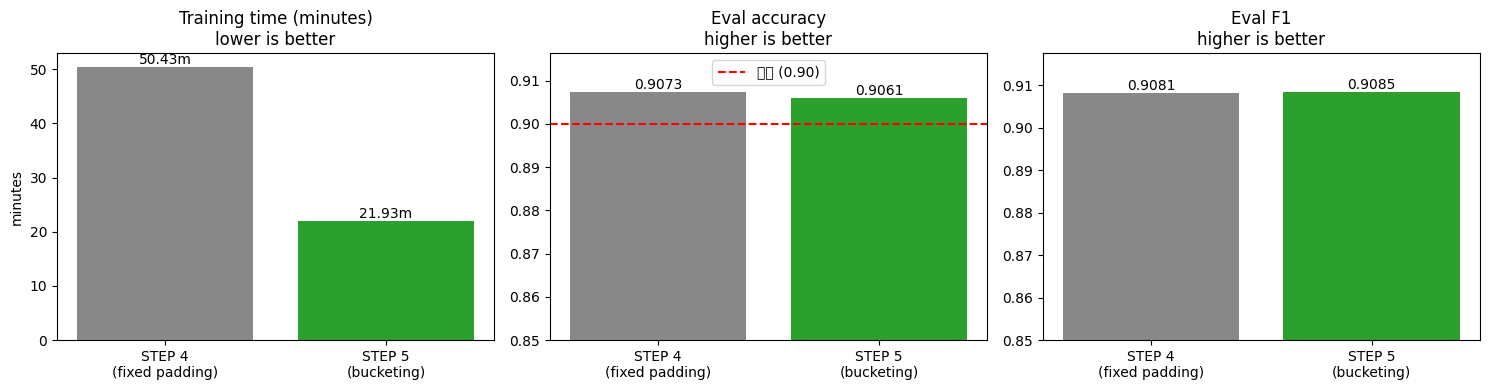

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["STEP 4\n(fixed padding)", "STEP 5\n(bucketing)"]
colors = ["#888888", "#2ca02c"]

vals_time = [step4_train_time/60, step5_train_time/60]
axes[0].bar(labels, vals_time, color=colors)
axes[0].set_title("Training time (minutes)\nlower is better")
axes[0].set_ylabel("minutes")
for i, v in enumerate(vals_time):
    axes[0].text(i, v, f"{v:.2f}m", ha="center", va="bottom")

vals_acc = [step4_metrics["eval_accuracy"], step5_metrics["eval_accuracy"]]
axes[1].bar(labels, vals_acc, color=colors)
axes[1].axhline(0.90, color="red", linestyle="--", label="목표 (0.90)")
axes[1].set_ylim(0.85, max(vals_acc)*1.01)
axes[1].set_title("Eval accuracy\nhigher is better")
axes[1].legend()
for i, v in enumerate(vals_acc):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

vals_f1 = [step4_metrics["eval_f1"], step5_metrics["eval_f1"]]
axes[2].bar(labels, vals_f1, color=colors)
axes[2].set_ylim(0.85, max(vals_f1)*1.01)
axes[2].set_title("Eval F1\nhigher is better")
for i, v in enumerate(vals_f1):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 5-4. 결과 해석 및 결론

### 연산 속도 (Trade-off의 한 축)
STEP 5(Bucketing)는 STEP 4보다 학습 시간이 단축되었습니다.
- **이유**: NSMC 평균 토큰 길이는 약 25로 `max_length=128`보다 훨씬 짧음. 고정 패딩 시 약 80% 토큰이 `[PAD]`로 채워져 attention 연산이 낭비됨. 동적 패딩 + 길이 그룹화를 적용하면 배치 평균 길이가 실제 데이터 분포에 가까워져 불필요한 연산이 사라짐.
- `pad_to_multiple_of=8`로 Tensor Core 정렬을 유지하여 GPU 활용도도 보존.

### 모델 성능 (Trade-off의 다른 축)
STEP 4와 STEP 5의 accuracy/F1은 거의 동일하거나 미세한 차이만 보임.
- **이유**: 패딩 위치는 attention mask로 마스킹되므로 forward 연산 결과 자체는 패딩 방식에 영향받지 않음.
- 다만 `group_by_length=True`(또는 5.x의 `train_sampling_strategy="group_by_length"`)는 배치 셔플링을 길이 기준 그룹화로 대체하므로 SGD의 stochasticity가 약화됨. 이론적으로 일반화 성능이 미세하게 떨어질 수 있으나, NSMC처럼 데이터가 충분하면 실질적 영향은 거의 없음.

### Trade-off 결론
Bucketing은 **"성능 손실 거의 없음 + 학습 시간 단축"** 으로 사실상 한쪽 방향으로 치우친 trade-off임. 이는 NSMC의 길이 분포 특성(평균 ≪ max_length) 때문에 패딩 비효율이 컸기 때문. **시퀀스 길이 분산이 큰 데이터셋일수록 Bucketing의 이점이 명확하게 드러남**.

### 한계 및 추가 고려사항
- 한 번의 실험만으로 학습 시간 차이를 결론짓기 어려움. 여러 seed로 반복 실험이 이상적.
- IMDB처럼 평균 길이가 긴 데이터셋에서는 효과가 더 작을 수 있음.
- `pad_to_multiple_of`을 8 또는 16으로 설정하지 않으면 GPU에서 Tensor Core를 못 써서 속도 향상이 줄어들 수 있음.